In [12]:
import os
import random
from glob import glob

import numpy as np
import torch
import torch.nn as nn
import timm
import yaml
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture

from muflow import constants as const

# Enable loading of truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# === Hyperparameters ===
model_name = "resnet50"  # Change this to your desired backbone
config_path = f"../configs/{model_name}.yaml"
config = yaml.safe_load(open(config_path, "r"))
print("Model config: ", config)

# === Model Setup ===
out_indices  = config.get("out_indices", [1, 2, 3])
pooling_type = config.get("pooling_type", "mean")
print(f"Using out_indices : {out_indices}")
print(f"Using pooling_type: {pooling_type}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if model_name in const.DINO_BACKBONES:
    timm_name    = const.DINO_TIMM_NAMES[model_name]
    model        = timm.create_model(timm_name, pretrained=True,
                                     img_size=config['input_size'])
    channels     = [const.DINO_CHANNELS[model_name]] * len(out_indices)
    scales       = [const.DINO_PATCH_SIZE[model_name]] * len(out_indices)
    backbone_type = 'dino'
elif model_name in const.CLIP_BACKBONES:
    from muflow.model import CLIPVisualExtractor
    model        = CLIPVisualExtractor(model_name, out_block_indices=out_indices)
    channels     = [const.CLIP_CHANNELS[model_name]] * len(out_indices)
    scales       = [const.CLIP_PATCH_SIZE[model_name]] * len(out_indices)
    backbone_type = 'clip'
elif model_name in [const.BACKBONE_CAIT, const.BACKBONE_DEIT]:
    model        = timm.create_model(model_name, pretrained=True, in_chans=3)
    channels     = [768]
    scales       = [16]
    backbone_type = 'cait_deit'
else:
    model        = timm.create_model(model_name, pretrained=True,
                                     features_only=True, out_indices=out_indices,
                                     in_chans=3)
    channels     = model.feature_info.channels()
    scales       = model.feature_info.reduction()
    backbone_type = 'cnn'

model.eval().to(DEVICE)
num_layers = len(out_indices)
print(f"Backbone type  : {backbone_type}")
print(f"Channels/layer : {channels}")
print(f"Scales/layer   : {scales}")
print(f"Number of layers: {num_layers}")

# Create output directory for plots
os.makedirs('.pictures', exist_ok=True)


# === Helper Functions ===
_imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def get_features(img):
    """Extract features from a (H, W, 3) uint8/float numpy array.

    Applies ImageNet normalisation before forwarding.
    CLIPVisualExtractor handles its own renormalisation internally.
    """
    t = torch.from_numpy(np.array(img)).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    t = (t - _imagenet_mean) / _imagenet_std
    t = t.to(DEVICE)
    with torch.no_grad():
        if backbone_type == 'dino':
            features = model.get_intermediate_layers(t, n=list(out_indices), reshape=True)
        elif backbone_type in ('clip', 'cnn'):
            features = model(t)
        else:  # cait_deit
            features = [model(t)]
    return features


def get_features_from_path(path):
    """Load image from path and extract features."""
    img = np.array(Image.open(path).convert("RGB").resize(
        [config['input_size'], config['input_size']], Image.BILINEAR
    ))
    return get_features(img)


def calculate_fourier_spectrum(image):
    """Calculate Fourier spectrum of an image."""
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    return magnitude_spectrum


def build_generators_dict(patterns_dict):
    """Build a dictionary mapping generator names to lists of image paths."""
    return {
        'ffhq': glob(patterns_dict.get('ffhq', '')),
        'WDF Real': glob(patterns_dict.get('WDF Real', '')),
        'celeba_hq': glob(patterns_dict.get('celeba_hq', '')),


        'Flux.1': glob(patterns_dict.get('Flux.1', '')),
        'Stable DIffusion 3.5': glob(patterns_dict.get('Stable DIffusion 3.5', '')),
        'Starry AI': glob(patterns_dict.get('Starry AI', '')),
        'StyleGAN3': glob(patterns_dict.get('StyleGAN3', '')),
        'Stable Diffusion XL': glob(patterns_dict.get('Stable Diffusion XL', '')),
        'SD Attend and Excite': glob(patterns_dict.get('Stable Diffusion Attend and Excite', '')),
        'Midjourney': glob(patterns_dict.get('Midjourney', '')),
        'Stable Cascade': glob(patterns_dict.get('Stable Cascade', '')),
        'Flux.1.1 Pro': glob(patterns_dict.get('Flux.1.1 Pro', '')),
        'Deep AI': glob(patterns_dict.get('Deep AI', '')),
        'StyleGAN2': glob(patterns_dict.get('StyleGAN2', '')),
        'Hotpot AI': glob(patterns_dict.get('Hotpot AI', '')),
        'Tencent Hunyuan': glob(patterns_dict.get('Tencent Hunyuan', '')),
        'Dall-E 3': glob(patterns_dict.get('Dall-E 3', '')),
        'StyleGAN': glob(patterns_dict.get('StyleGAN', '')),
        'Nvidia Sana PAG': glob(patterns_dict.get('Nvidia Sana PAG', '')),
        'StarGAN': glob(patterns_dict.get('STARGAN', '')),
        'AttGAN': glob(patterns_dict.get('ATTGAN', '')),
        'GDWCT': glob(patterns_dict.get('GDWCT', ''))
    }


def plot_generators_grid(generators_dict, save_path, cols=7):
    """Plot a grid of sample images from each generator."""
    num_generators = len(generators_dict)
    rows = (num_generators + cols - 1) // cols
    
    plt.figure(figsize=(3 * cols, 3 * rows))
    
    for idx, (name, img_list) in enumerate(generators_dict.items()):
        if not img_list:
            continue
        
        img_path = random.choice(img_list)
        try:
            img = Image.open(img_path).convert("RGB")
            img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255
            
            ax = plt.subplot(rows, cols, idx + 1)
            ax.imshow(img_tensor.permute(1, 2, 0))
            ax.set_title(name, fontsize=20)
            ax.axis('off')
        except Exception as e:
            print(f"Error with image {img_path}: {e}")
            continue
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.15, wspace=0.001)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved grid to {save_path}")


def extract_features_by_class(patterns_dict, sample_size=100, num_layers=3, pooling_type='mean'):
    """Extract features from images grouped by class/generator.
    
    Args:
        patterns_dict: Dictionary mapping labels to file patterns
        sample_size: Number of samples per class
        num_layers: Number of feature layers to extract
        pooling_type: Type of spatial pooling ('mean', 'max', 'mean_std', 'flatten')
    """
    features_by_class = {}
    labels = []
    
    for label, pattern in patterns_dict.items():
        files = glob(pattern)
        if not files:
            print(f"[!] No files found for {label}. Skipping.")
            continue
        
        sample = random.sample(files, min(sample_size, len(files)))
        layer_features = {i: [] for i in range(num_layers)}
        
        for img_path in sample:
            try:
                features = get_features_from_path(img_path)
                for i in range(len(features)):
                    feats = features[i]
                    
                    # Apply pooling based on pooling_type
                    if pooling_type == 'mean':
                        # Spatial pooling: (B, C, H, W) -> (B, C)
                        vec = feats.mean(dim=(2, 3)).flatten().cpu().numpy()
                    elif pooling_type == 'max':
                        # Max pooling: (B, C, H, W) -> (B, C)
                        vec = feats.flatten(2).max(-1)[0].cpu().numpy().squeeze(0)
                    elif pooling_type == 'mean_std':
                        # Mean + Std concatenation: (B, C, H, W) -> (B, 2*C)
                        mean_feats = feats.mean(dim=(2, 3)).flatten().cpu().numpy()
                        std_feats = feats.std(dim=(2, 3)).flatten().cpu().numpy()
                        vec = np.concatenate([mean_feats, std_feats])
                    else:  # flatten
                        # Mean on channels, then flatten spatial: (B, C, H, W) -> (B, H, W) -> (B, H*W)
                        vec = feats.mean(1).flatten(1).cpu().numpy().squeeze(0)
                    
                    layer_features[i].append(vec)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue
        
        features_by_class[label] = {
            i: np.array(layer_features[i]) for i in range(len(layer_features))
        }
        if len(layer_features[0]) > 0:
            labels.extend([label] * len(layer_features[0]))
    
    return features_by_class, labels


def _tsne_scatter(ax, features_by_class, layer_idx, colors_dict):
    """Run t-SNE on one set of features and scatter-plot onto *ax*.

    Returns a list of (handle, label) for the legend.
    """
    valid_labels = [l for l in features_by_class
                    if len(features_by_class[l][layer_idx]) > 0]
    if not valid_labels:
        return []

    all_features = np.vstack([features_by_class[l][layer_idx]
                              for l in valid_labels])
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(all_features)

    handles = []
    start = 0
    for label in valid_labels:
        count = len(features_by_class[label][layer_idx])
        subset_2d = features_2d[start:start + count]
        h = ax.scatter(
            subset_2d[:, 0], subset_2d[:, 1],
            label=label,
            c=colors_dict.get(label, 'gray'),
            alpha=0.6,
            s=15
        )
        handles.append((h, label))
        start += count

    ax.grid(True, linestyle='--', alpha=0.6)
    return handles


# === Color mapping for plotting ===
colors = {
    'Leonardo AI': 'lightcoral',
    'Flux.1': 'lightskyblue',

    'ffhq': 'black',
    'celeba_hq': 'crimson',
    # 'WDF Real': 'dimgray',

    'Stable DIffusion 3.5': 'lightseagreen',
    'Freepik': 'paleturquoise',
    'Starry AI': 'hotpink',
    'StyleGAN3': 'mediumpurple',
    'Stable Diffusion XL': 'lightgreen',
    'Stable Diffusion Attend and Excite': 'palegreen',
    'SD Attend and Excite': 'mediumspringgreen',
    'Dall-E': 'lightsteelblue',
    'Midjourney': 'violet',
    'Stable Cascade': 'cornflowerblue',
    'Adobe Firefly': 'lightsalmon',
    'Flux.1.1 Pro': 'khaki',
    'Deep AI': 'gold',
    'StyleGAN2': 'mediumaquamarine',
    'Hotpot AI': 'salmon',
    'Tencent Hunyuan': 'silver',
    'Dall-E 3': 'gainsboro',
    'StyleGAN': 'rosybrown',
    'Nvidia Sana PAG': 'lemonchiffon',
    'StarGAN': 'steelblue',
    'AttGAN': 'orchid',
    'GDWCT': 'yellowgreen'
}


common_path = "/media/orazio_mattia_group/ad4dd/WILD"
patterns = {}

# Get generators from Closed Set
closed_set_path = os.path.join(common_path, 'Closed Set')
if os.path.exists(closed_set_path):
    generators = [folder for folder in os.listdir(closed_set_path) 
                  if os.path.isdir(os.path.join(closed_set_path, folder))]
    for gen in generators:
        patterns[gen] = os.path.join(closed_set_path, gen, '*.png')

# Get generators from Open Set
open_set_path = os.path.join(common_path, 'Open Set')
if os.path.exists(open_set_path):
    generators = [folder for folder in os.listdir(open_set_path) 
                  if os.path.isdir(os.path.join(open_set_path, folder))]
    for gen in generators:
        patterns[gen] = os.path.join(open_set_path, gen, '*.png')

dfx_common_path = '/media/orazio_mattia_group/ad4dd/datasets_DFX'
if os.path.exists(dfx_common_path):
    dfx_generators = [folder for folder in os.listdir(dfx_common_path) 
                      if os.path.isdir(os.path.join(dfx_common_path, folder))]
    for gen in dfx_generators:
        patterns[gen] = os.path.join(dfx_common_path, gen, '*.png')

# Add real image datasets
patterns['ffhq'] = '/media/orazio_mattia_group/ad4dd/ffhq/*/*.png'
patterns['celeba_hq'] = '/media/orazio_mattia_group/ad4dd/celeba_hq/*/*/*.jpg'
# patterns['WDF Real'] = '/media/orazio_mattia_group/ad4dd/WildDeepfake/deepfake_in_the_wild/real_*/*/real/*/*.png'

# Build generators dictionary
generators_dict_single = build_generators_dict(patterns)

common_path_means = "/media/orazio_mattia_group/ad4dd/WILD_means/500"
patterns_means = {}

if os.path.exists(common_path_means):
    generators_means = os.listdir(common_path_means)
    if 'WDF Real' in generators_means:
        generators_means.remove('WDF Real')
    for gen in generators_means:
        patterns_means[gen] = os.path.join(common_path_means, gen, '*.png')
else:
    print(f"Warning: Mean images path does not exist: {common_path_means}")

# Build generators dictionary for means
generators_dict_means = build_generators_dict(patterns_means)

Model config:  {'input_size': 256, 'backbone_name': 'resnet50', 'flow_step': 8, 'hidden_ratio': 1.0, 'conv3x3_only': True, 'pooling_type': 'flatten', 'gmm_n_components': 1, 'out_indices': [1, 2, 3]}
Using out_indices : [1, 2, 3]
Using pooling_type: flatten


Backbone type  : cnn
Channels/layer : [256, 512, 1024]
Scales/layer   : [4, 8, 16]
Number of layers: 3


In [13]:
# Plot grid of sample images
print("Plotting sample images grid...")
plot_generators_grid(generators_dict_single, f'.pictures/single_images_grid.png')

# Extract features
print("Extracting features from single images...")
features_by_class_single, labels_single = extract_features_by_class(patterns, sample_size=100, num_layers=num_layers, pooling_type=pooling_type)

# Plot grid of mean images
print("Plotting mean images grid...")
plot_generators_grid(generators_dict_means, f'.pictures/_mean_images_grid.png')

# Extract features from mean images
print("Extracting features from mean images...")
features_by_class_means, labels_means = extract_features_by_class(patterns_means, sample_size=100, num_layers=num_layers, pooling_type=pooling_type)

Plotting sample images grid...
Saved grid to .pictures/single_images_grid.png
Extracting features from single images...
Plotting mean images grid...
Saved grid to .pictures/_mean_images_grid.png
Extracting features from mean images...


Applying t-SNE for layer 0 (paired)...


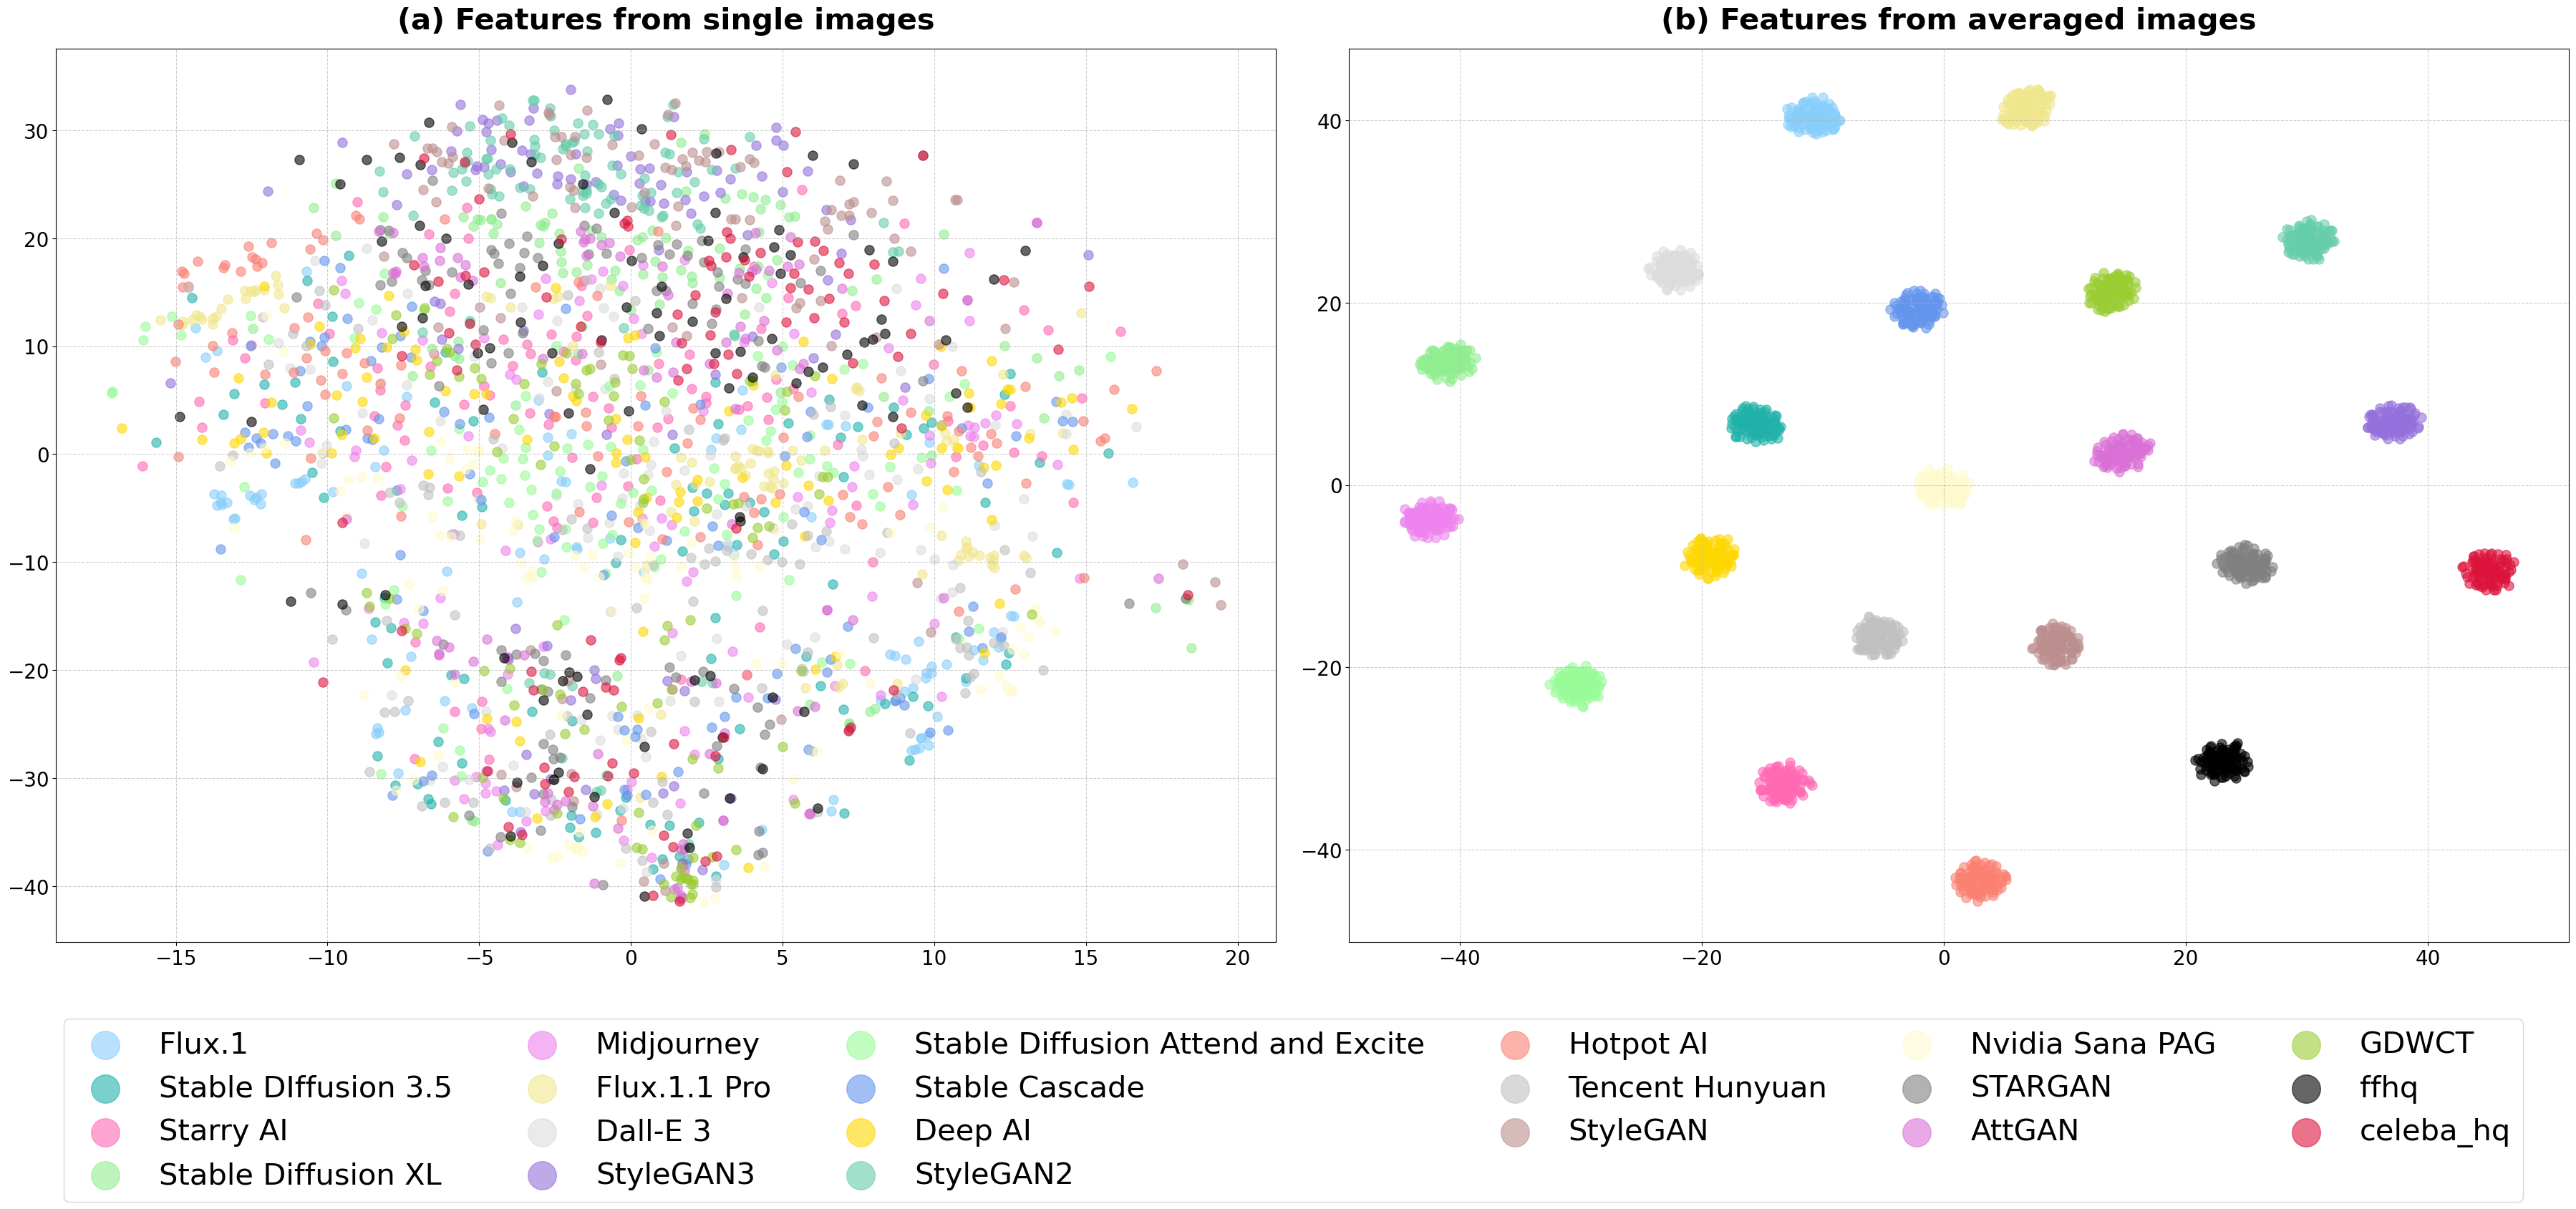

Saved to .pictures/analysis-resnet50_tsne_paired_flatten_layer_0.png
Applying t-SNE for layer 1 (paired)...


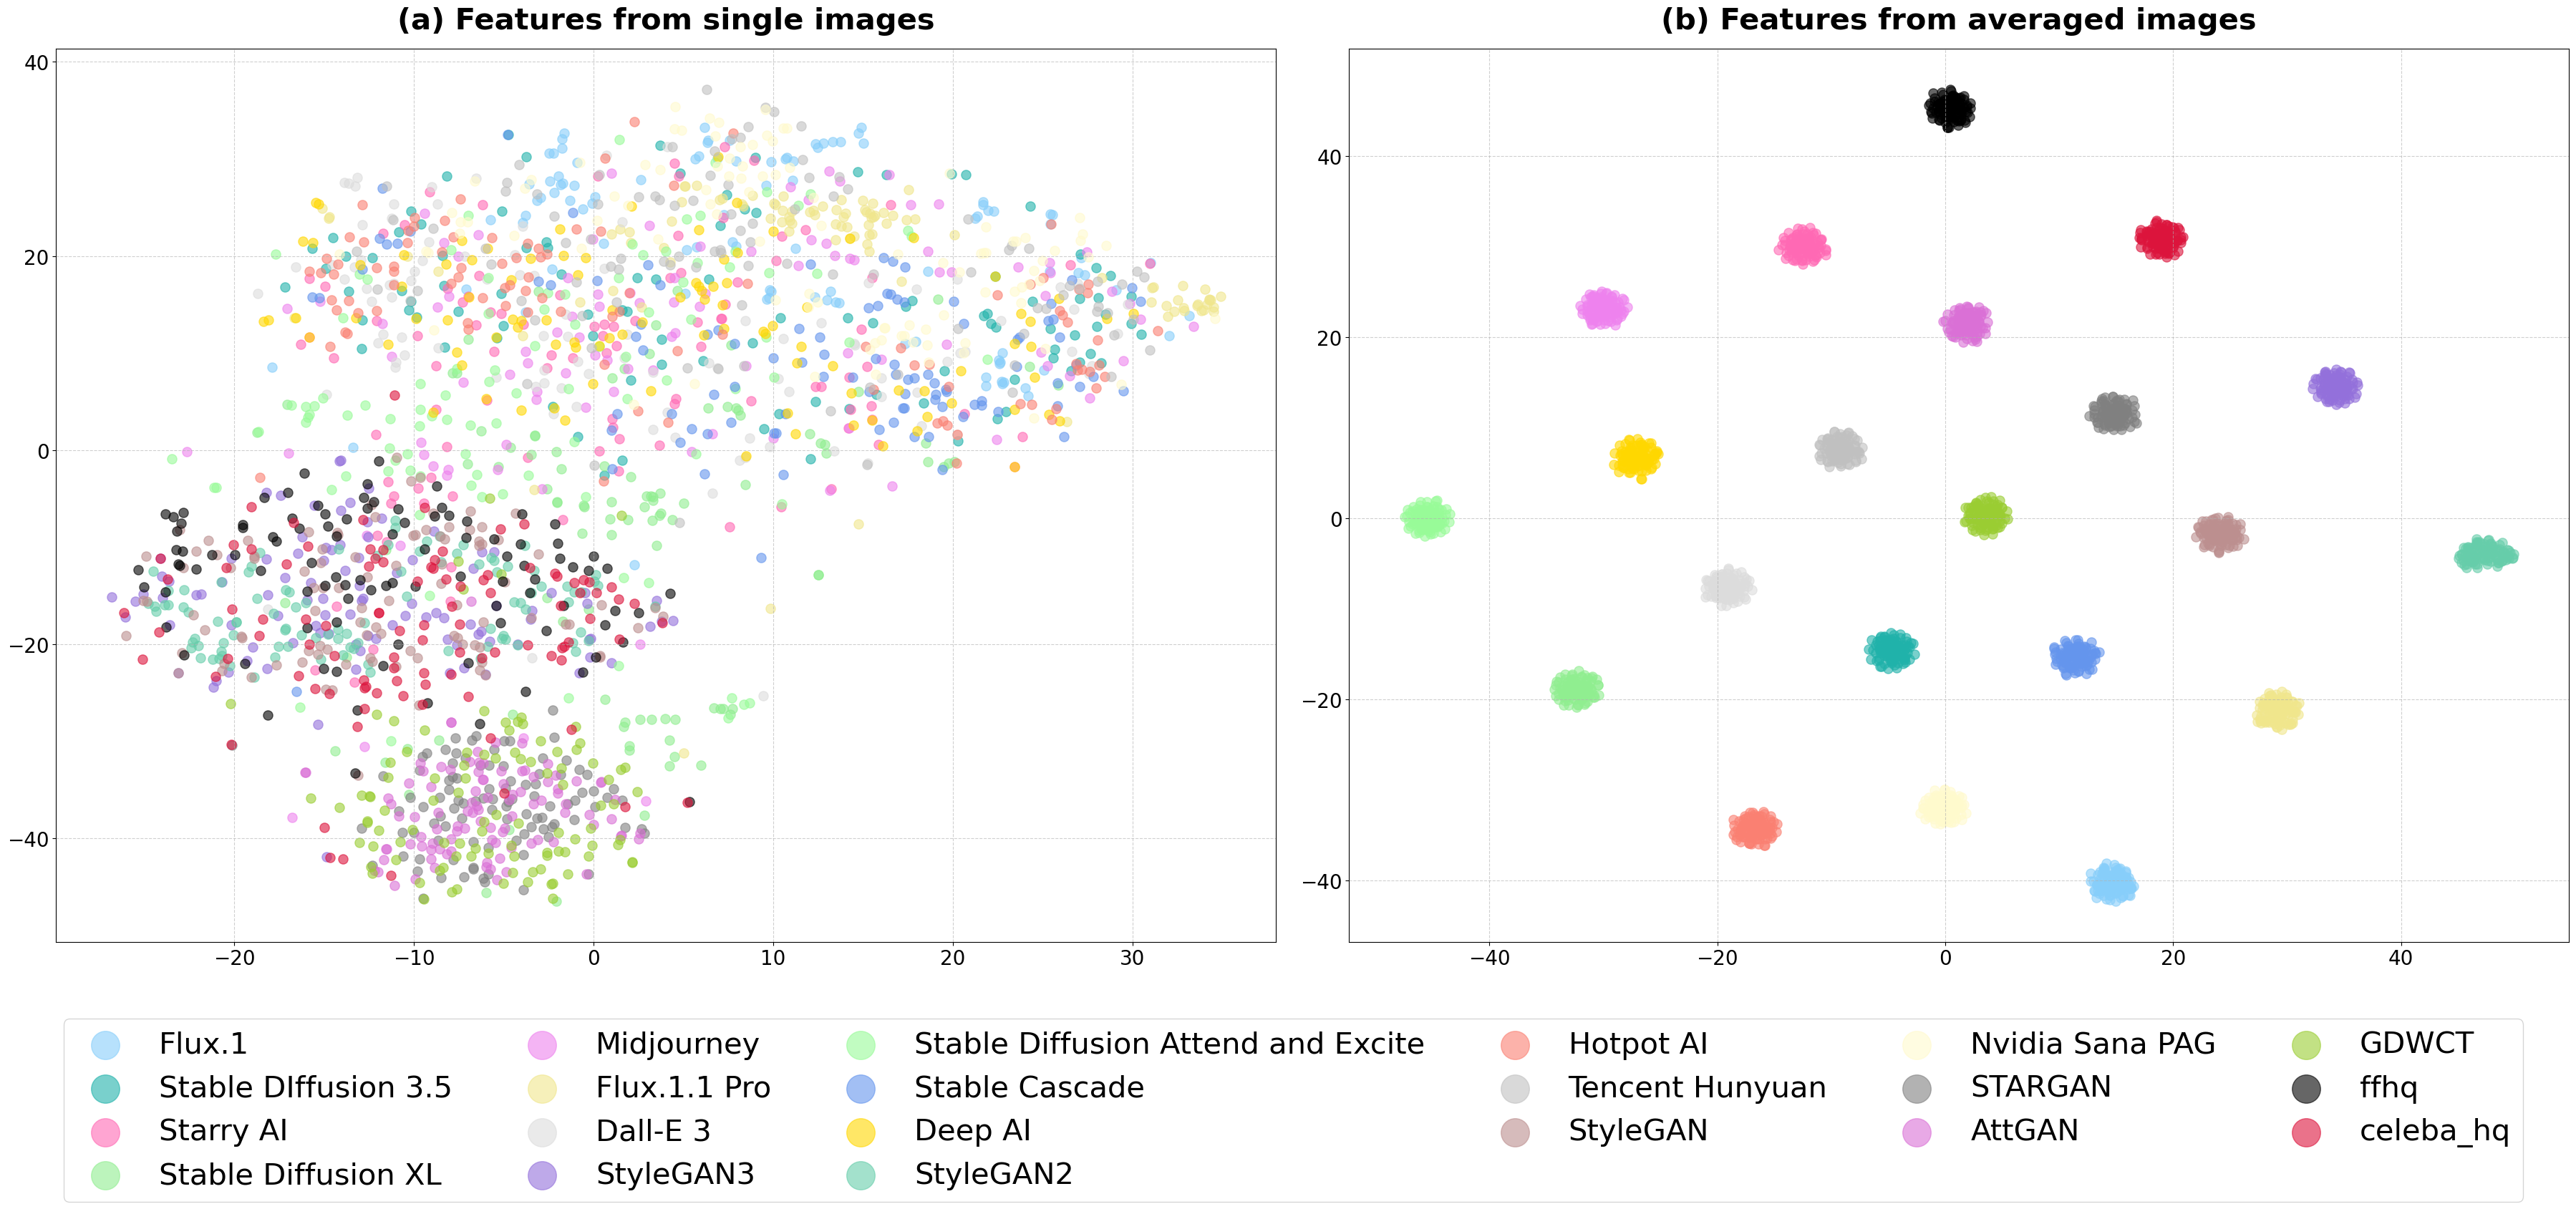

Saved to .pictures/analysis-resnet50_tsne_paired_flatten_layer_1.png
Applying t-SNE for layer 2 (paired)...


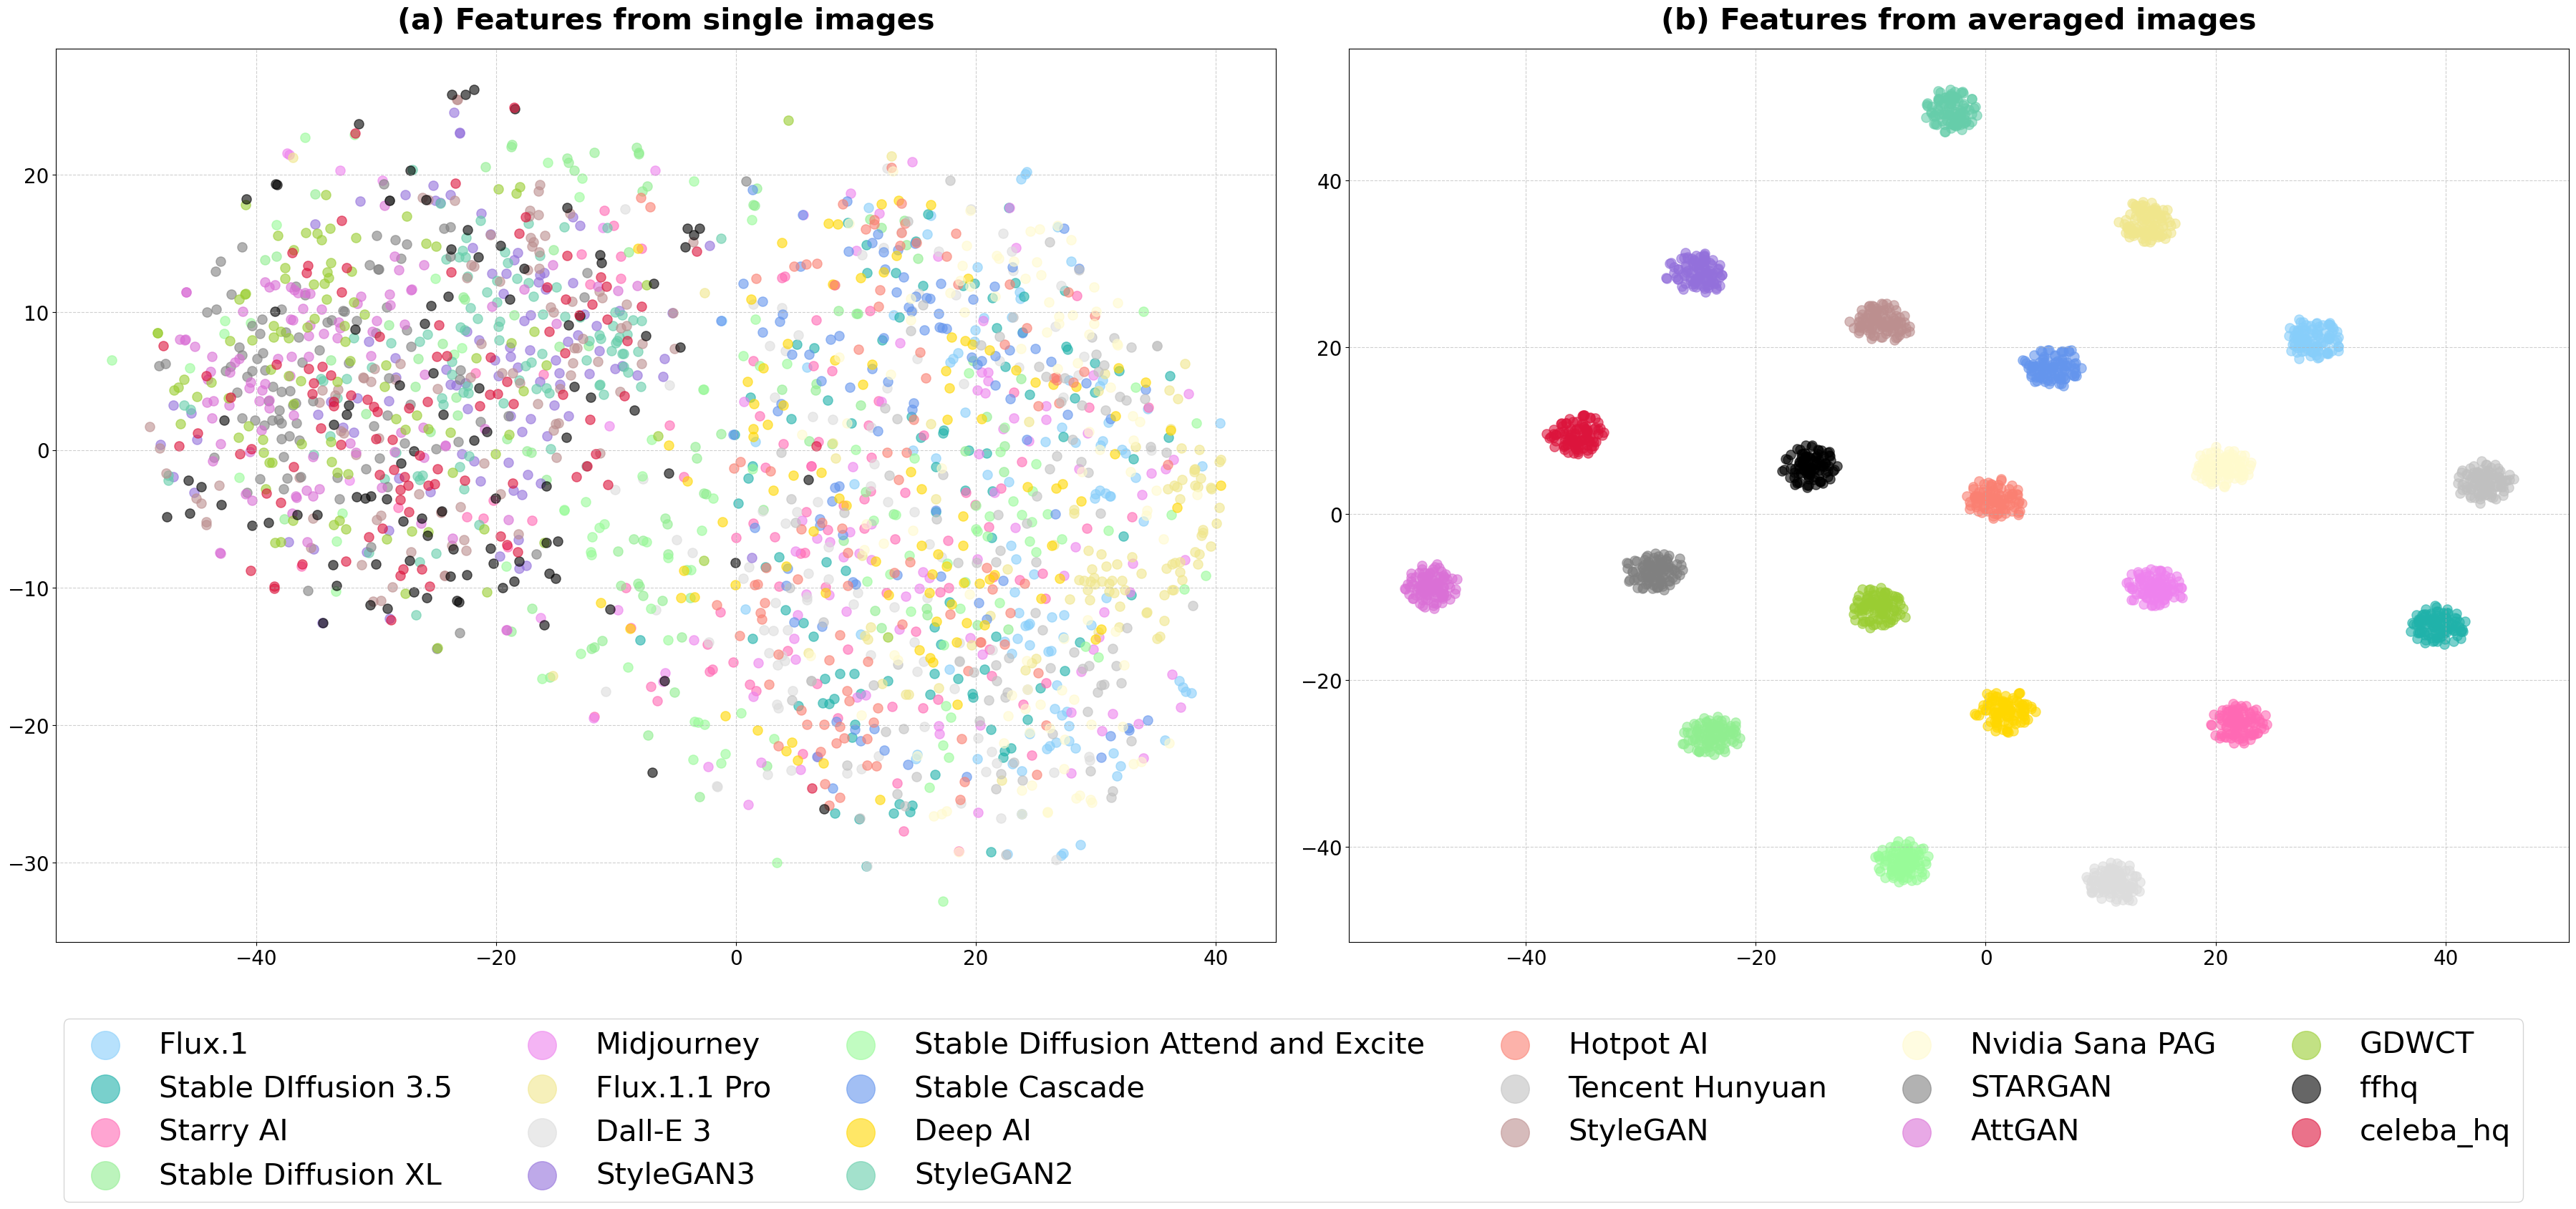

Saved to .pictures/analysis-resnet50_tsne_paired_flatten_layer_2.png


In [ ]:
def _tsne_scatter(ax, features_by_class, layer_idx, colors_dict, alpha=0.6, s=15):
    """Run t-SNE on one layer and scatter-plot on ax."""
    valid_labels = [
        l for l in features_by_class
        if layer_idx in features_by_class[l] and len(features_by_class[l][layer_idx]) > 0
    ]
    if not valid_labels:
        return []

    all_features = np.vstack([features_by_class[l][layer_idx] for l in valid_labels])
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(all_features)

    handles = []
    start = 0
    for label in valid_labels:
        count = len(features_by_class[label][layer_idx])
        subset_2d = features_2d[start:start + count]
        h = ax.scatter(
            subset_2d[:, 0], subset_2d[:, 1],
            label=label,
            c=colors_dict.get(label, 'gray'),
            alpha=alpha,
            s=s
        )
        handles.append((h, label))
        start += count

    ax.grid(True, linestyle='--', alpha=0.6)
    return handles


def plot_tsne_paired(features_single, features_means, colors_dict,
                     save_prefix, num_layers=None, alpha=0.6, s=90):
    """Create side-by-side t-SNE plots (single | means) with shared legend."""
    if num_layers is None:
        num_layers = len(next(iter(features_single.values())))

    for layer_idx in range(num_layers):
        print(f"Applying t-SNE for layer {layer_idx} (paired)...")

        fig, (ax_left, ax_right) = plt.subplots(
            1, 2, figsize=(36, 16), gridspec_kw={"wspace": 0.06}
        )

        handles_left = _tsne_scatter(
            ax_left, features_single, layer_idx, colors_dict, alpha=alpha, s=s
        )
        ax_left.set_title('(a) Features from single images', fontsize=30, fontweight='bold', pad=20)
        ax_left.tick_params(axis='both', which='major', labelsize=20)

        handles_right = _tsne_scatter(
            ax_right, features_means, layer_idx, colors_dict, alpha=alpha, s=s
        )
        ax_right.set_title('(b) Features from averaged images', fontsize=30, fontweight='bold', pad=20)
        ax_right.tick_params(axis='both', which='major', labelsize=20)

        seen = set()
        legend_handles, legend_labels = [], []
        for h, lbl in handles_left + handles_right:
            if lbl not in seen:
                seen.add(lbl)
                legend_handles.append(h)
                legend_labels.append(lbl)

        if legend_handles:
            fig.legend(
                legend_handles, legend_labels,
                loc='lower center',
                ncol=min(6, len(legend_labels)),
                bbox_to_anchor=(0.5, -0.1),
                frameon=True,
                fontsize=30,
                markerscale=3
            )

        fig.subplots_adjust(left=0.02, right=0.995, top=0.92, bottom=0.14, wspace=0.06)

        save_path = f'.pictures/{save_prefix}_{pooling_type}_layer_{layer_idx}.png'
        fig.savefig(save_path, dpi=400)
        plt.show()
        print(f"Saved to {save_path}")


plot_tsne_paired(
    features_by_class_single,
    features_by_class_means,
    colors,
    f'analysis-{model_name}_tsne_paired',
    num_layers=num_layers,
    alpha=0.6,
    s=90
)

# Paper Imges

In [7]:
# ============================================================================
# PARTE 1: COMPUTAZIONE E SALVATAGGIO DATI
# ============================================================================

import os
from glob import glob
import random
import numpy as np
import pickle
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.cluster import adjusted_rand_score
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# Valori di k da iterare
k_values = [50, 100, 200, 300, 400, 500, 600, 700]

sample_size = 100

# Storage per le metriche
clustering_metrics = {
    'Silhouette Score': [],
    'Calinski-Harabasz Index': [],
    'Davies-Bouldin Index': [],
    'Adjusted Rand Index': []
}

# Storage per i plot t-SNE
tsne_plots_data = []

# Iterazione su tutti i valori di k
for k in k_values:
    print(f"\n{'='*60}")
    print(f"Processing k = {k}")
    print(f"{'='*60}\n")
    
    common_path = f"/media/orazio_mattia_group/ad4dd/FF4ALL_means/{k}"
    
    if not os.path.exists(common_path):
        print(f"[!] Path not found for k={k}: {common_path}. Skipping.")
        continue
    
    generators = os.listdir(common_path)
    patterns_means = {}
    
    for gen in generators:
        patterns_means[gen] = os.path.join(common_path, gen, '*.png')
    
    # Costruzione del dizionario patterns per ogni generatore
    patterns = {}
    
    if 'Flux.1' in patterns_means:
        patterns['Flux.1'] = patterns_means['Flux.1']
    if 'ffhq' in patterns_means:
        patterns['ffhq'] = patterns_means['ffhq']
    if 'Stable DIffusion 3.5' in patterns_means:
        patterns['Stable DIffusion 3.5'] = patterns_means['Stable DIffusion 3.5']
    if 'Starry AI' in patterns_means:
        patterns['Starry AI'] = patterns_means['Starry AI']
    if 'StyleGAN3' in patterns_means:
        patterns['StyleGAN3'] = patterns_means['StyleGAN3']
    if 'Stable Diffusion XL' in patterns_means:
        patterns['Stable Diffusion XL'] = patterns_means['Stable Diffusion XL']
    if 'Stable Diffusion Attend and Excite' in patterns_means:
        patterns['Stable Diffusion Attend and Excite'] = patterns_means['Stable Diffusion Attend and Excite']
    if 'Midjourney' in patterns_means:
        patterns['Midjourney'] = patterns_means['Midjourney']
    if 'Stable Cascade' in patterns_means:
        patterns['Stable Cascade'] = patterns_means['Stable Cascade']
    if 'Flux.1.1 Pro' in patterns_means:
        patterns['Flux.1.1 Pro'] = patterns_means['Flux.1.1 Pro']
    if 'Deep AI' in patterns_means:
        patterns['Deep AI'] = patterns_means['Deep AI']
    if 'StyleGAN2' in patterns_means:
        patterns['StyleGAN2'] = patterns_means['StyleGAN2']
    if 'celeba_hq' in patterns_means:
        patterns['celeba_hq'] = patterns_means['celeba_hq']
    if 'Hotpot AI' in patterns_means:
        patterns['Hotpot AI'] = patterns_means['Hotpot AI']
    if 'Tencent Hunyuan' in patterns_means:
        patterns['Tencent Hunyuan'] = patterns_means['Tencent Hunyuan']
    if 'Dall-E 3' in patterns_means:
        patterns['Dall-E 3'] = patterns_means['Dall-E 3']
    if 'StyleGAN' in patterns_means:
        patterns['StyleGAN'] = patterns_means['StyleGAN']
    if 'Nvidia Sana PAG' in patterns_means:
        patterns['Nvidia Sana PAG'] = patterns_means['Nvidia Sana PAG']
    
    # === Process datasets ===
    features_by_class = {}
    labels = []
    label_indices = []
    
    for label_idx, (label, pattern) in enumerate(patterns.items()):
        files = glob(pattern)
        if not files:
            print(f"[!] No files found for {label}. Skipping.")
            continue
        sample = random.sample(files, min(sample_size, len(files)))
        print(f"Sample size for {label}: {len(sample)}")
        
        # Prepare per-layer containers
        layer_features = {}
        
        for img_path in sample:
            try:
                features = get_features_from_path(img_path)
                for i in range(len(features)):
                    vec = features[i].mean(dim=(2, 3)).flatten().cpu().numpy()
                    layer_features.setdefault(i, []).append(vec)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue
        
        features_by_class[label] = {
            i: np.array(layer_features[i]) for i in layer_features
        }
        labels.extend([label] * len(next(iter(layer_features.values()))))
        label_indices.extend([label_idx] * len(next(iter(layer_features.values()))))
    
    if not features_by_class:
        print(f"[!] No features extracted for k={k}. Skipping visualization.")
        continue
    
    # === Combine features and run t-SNE ===
    all_features = np.vstack([features_by_class[label][2]
                                for label in features_by_class])
    label_indices = np.array(label_indices)
    
    print("Running t-SNE...")
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(all_features)
    
    # Store data per il plot
    tsne_plots_data.append({
        'k': k,
        'features_2d': features_2d,
        'labels': labels,
        'features_by_class': features_by_class,
        'all_features': all_features,
        'label_indices': label_indices
    })
    
    # === Calcola metriche di clustering ===
    print("Computing clustering metrics...")
    
    # Silhouette Score (range: -1 to 1, higher is better)
    silhouette = silhouette_score(all_features, label_indices)
    clustering_metrics['Silhouette Score'].append(silhouette)
    
    # Calinski-Harabasz Index (higher is better)
    calinski = calinski_harabasz_score(all_features, label_indices)
    clustering_metrics['Calinski-Harabasz Index'].append(calinski)
    
    # Davies-Bouldin Index (lower is better)
    davies = davies_bouldin_score(all_features, label_indices)
    clustering_metrics['Davies-Bouldin Index'].append(davies)
    
    # Adjusted Rand Index (range: -1 to 1, 1 is perfect)
    # Per ARI usiamo una baseline random
    n_samples = len(label_indices)
    random_labels = np.random.randint(0, len(patterns), n_samples)
    ari = adjusted_rand_score(label_indices, random_labels)
    clustering_metrics['Adjusted Rand Index'].append(ari)
    
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Calinski-Harabasz Index: {calinski:.4f}")
    print(f"Davies-Bouldin Index: {davies:.4f}")
    print(f"Adjusted Rand Index: {ari:.4f}")

# === Salva tutti i dati computati ===
print("\n" + "="*60)
print("Saving computed data...")
print("="*60)

data_to_save = {
    'k_values': k_values,
    'tsne_plots_data': tsne_plots_data,
    'clustering_metrics': clustering_metrics
}

with open('computed_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("Data saved to 'computed_data.pkl'")
print("="*60)


Processing k = 50

Sample size for Flux.1: 100
Sample size for ffhq: 100
Sample size for Stable DIffusion 3.5: 100
Sample size for Starry AI: 100
Sample size for StyleGAN3: 100
Sample size for Stable Diffusion XL: 100
Sample size for Stable Diffusion Attend and Excite: 100
Sample size for Midjourney: 100
Sample size for Stable Cascade: 100
Sample size for Flux.1.1 Pro: 100
Sample size for Deep AI: 100
Sample size for StyleGAN2: 100
Sample size for celeba_hq: 100
Sample size for Hotpot AI: 100
Sample size for Tencent Hunyuan: 100
Sample size for Dall-E 3: 100
Sample size for StyleGAN: 100
Sample size for Nvidia Sana PAG: 100
Running t-SNE...
Computing clustering metrics...
Silhouette Score: 0.2514
Calinski-Harabasz Index: 712.0176
Davies-Bouldin Index: 1.6881
Adjusted Rand Index: -0.0004

Processing k = 100

Sample size for Flux.1: 100
Sample size for ffhq: 100
Sample size for Stable DIffusion 3.5: 100
Sample size for Starry AI: 100
Sample size for StyleGAN3: 100
Sample size for Stable


Loading computed data...
Loaded data for 8 K values
Creating t-SNE grid plot...
Saved grid plot: tsne_grid_all_k.png


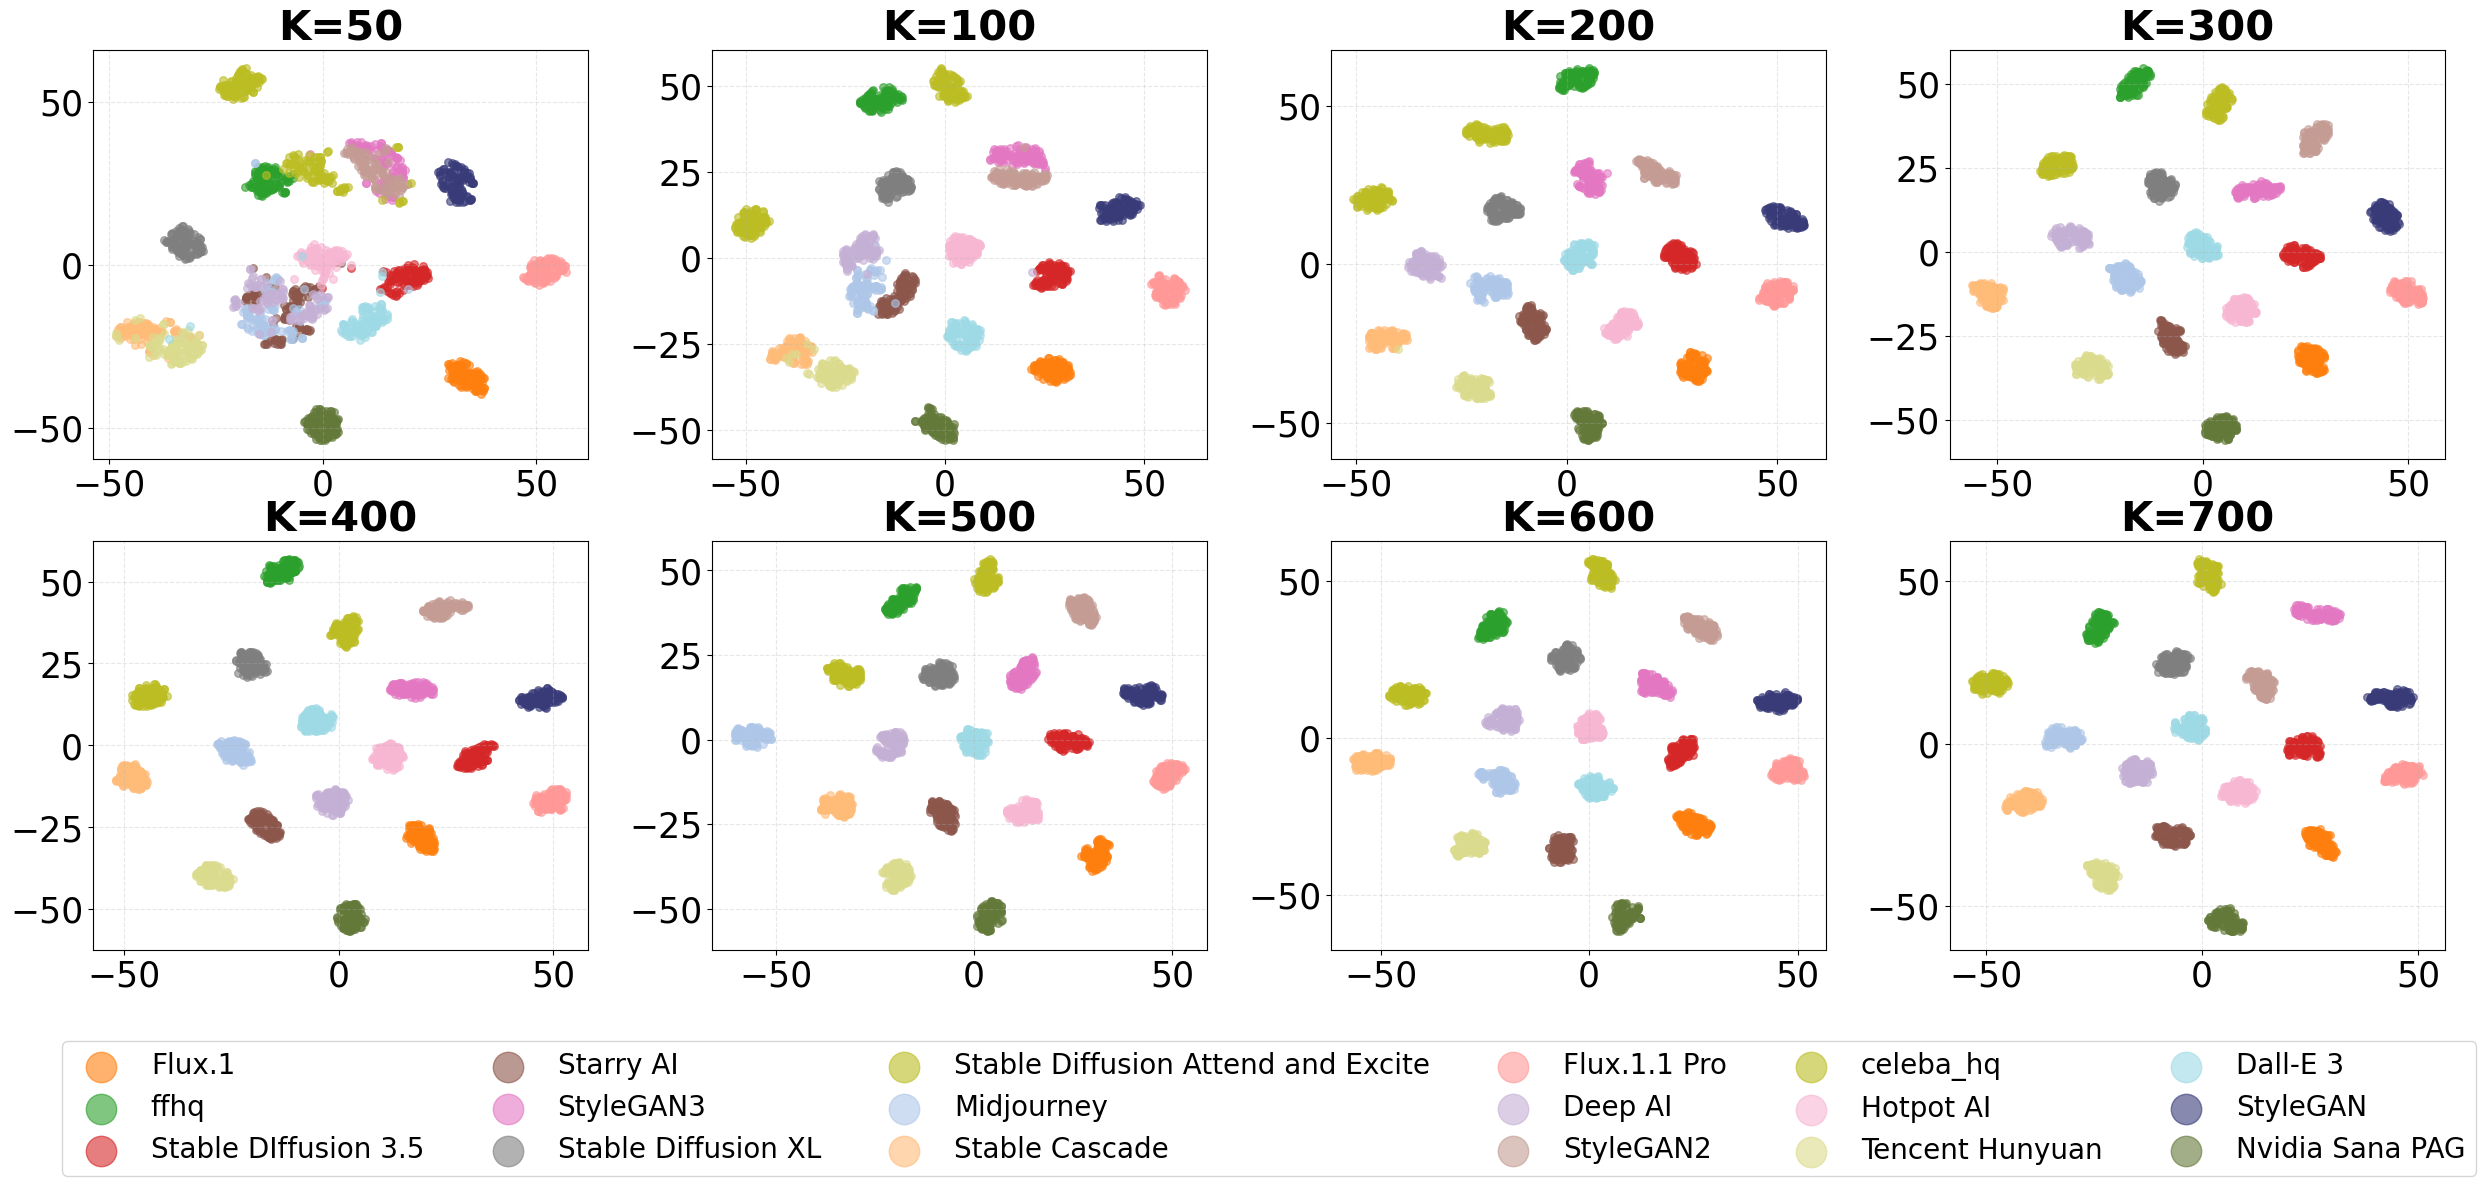

Creating clustering metrics plot...
Saved metrics plot: clustering_metrics.png


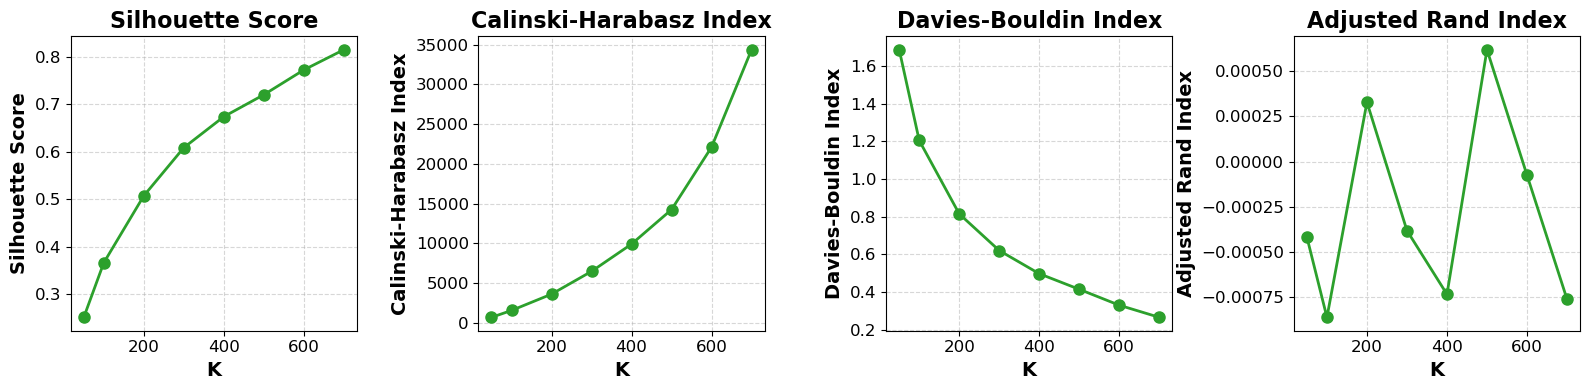


Plotting completed!


In [2]:
# ============================================================================
# PARTE 2: CARICAMENTO DATI E PLOTTING
# ============================================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt

# === Colors for plotting ===
colors = {
    'Leonardo AI': '#1f77b4',
    'Flux.1': '#ff7f0e',
    'ffhq': '#2ca02c',
    'Stable DIffusion 3.5': '#d62728',
    'Freepik': '#9467bd',
    'Starry AI': '#8c564b',
    'StyleGAN3': '#e377c2',
    'Stable Diffusion XL': '#7f7f7f',
    'Stable Diffusion Attend and Excite': '#bcbd22',
    'Dall-E': '#17becf',
    'Midjourney': '#aec7e8',
    'Stable Cascade': '#ffbb78',
    'Adobe Firefly': '#98df8a',
    'Flux.1.1 Pro': '#ff9896',
    'Deep AI': '#c5b0d5',
    'StyleGAN2': '#c49c94',
    'Hotpot AI': '#f7b6d2',
    'Tencent Hunyuan': '#dbdb8d',
    'Dall-E 3': '#9edae5',
    'StyleGAN': '#393b79',
    'Nvidia Sana PAG': '#637939',
    'celeba_hq': '#bcbd22'
}

print("\n" + "="*60)
print("Loading computed data...")
print("="*60)

# Carica i dati
with open('computed_data.pkl', 'rb') as f:
    data = pickle.load(f)

k_values = data['k_values']
tsne_plots_data = data['tsne_plots_data']
clustering_metrics = data['clustering_metrics']

print(f"Loaded data for {len(tsne_plots_data)} K values")

# === Crea griglia 4x2 dei plot t-SNE (2 righe x 4 colonne) ===
print("Creating t-SNE grid plot...")

fig = plt.figure(figsize=(24, 12))
gs = fig.add_gridspec(2, 4, hspace=0.2, wspace=0.25, bottom=0.2, top=0.95, left=0.01, right=0.99)

for idx, plot_data in enumerate(tsne_plots_data):
    row = idx // 4
    col = idx % 4
    ax = fig.add_subplot(gs[row, col])
    
    features_2d = plot_data['features_2d']
    features_by_class = plot_data['features_by_class']
    k = plot_data['k']
    
    start = 0
    for label in features_by_class:
        feats = features_by_class[label][2]
        count = len(feats)
        subset_2d = features_2d[start:start + count]
        ax.scatter(
            subset_2d[:, 0], subset_2d[:, 1],
            label=label,
            c=colors.get(label, 'gray'),
            alpha=0.6,
            s=30
        )
        start += count
    
    ax.set_title(f'K={k}', fontsize=30, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=25)

# Leggenda unica centrata in basso
handles, labels_legend = ax.get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='lower center', ncol=6, 
           bbox_to_anchor=(0.5, 0.0), frameon=True, fontsize=20, markerscale=4)

plt.savefig('tsne_grid_all_k.png', dpi=400, bbox_inches='tight')
print("Saved grid plot: tsne_grid_all_k.png")
plt.show()
plt.close()

# === Crea plot delle metriche di clustering ===
print("Creating clustering metrics plot...")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes = axes.flatten()

metric_names = list(clustering_metrics.keys())
for idx, metric_name in enumerate(metric_names):
    ax = axes[idx]
    metric_values = clustering_metrics[metric_name]
    k_vals = k_values[:len(metric_values)]
    
    ax.plot(k_vals, metric_values, 
            marker='o', linewidth=2, markersize=8, color='#2ca02c')
    ax.set_xlabel('K', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=14, fontweight='bold')
    ax.set_title(metric_name, fontsize=16, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('clustering_metrics.png', dpi=400, bbox_inches='tight')
print("Saved metrics plot: clustering_metrics.png")
plt.show()
plt.close()

print("\n" + "="*60)
print("Plotting completed!")
print("="*60)

In [2]:
metric_values = [0.2514201,
 0.3663035,
 0.5071681,
 0.6084731,
 0.6737465,
 0.7199053,
 0.72611803,
 0.73062646]

metric_name = "Silhouette Score"


k_vals = k_values[:len(metric_values)]

plt.figure(figsize=(8, 5))

plt.plot(
    k_vals,
    metric_values,
    marker='o',
    linewidth=2,
    markersize=8,
    color='#2ca02c'
)

plt.xlabel('K', fontsize=14, fontweight='bold')
plt.ylabel(metric_name, fontsize=14, fontweight='bold')
# plt.title(metric_name, fontsize=16, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('silhouette.png', dpi=400, bbox_inches='tight')
print("Saved metrics plot: silhouette.png")
plt.show()
plt.close()

NameError: name 'k_values' is not defined

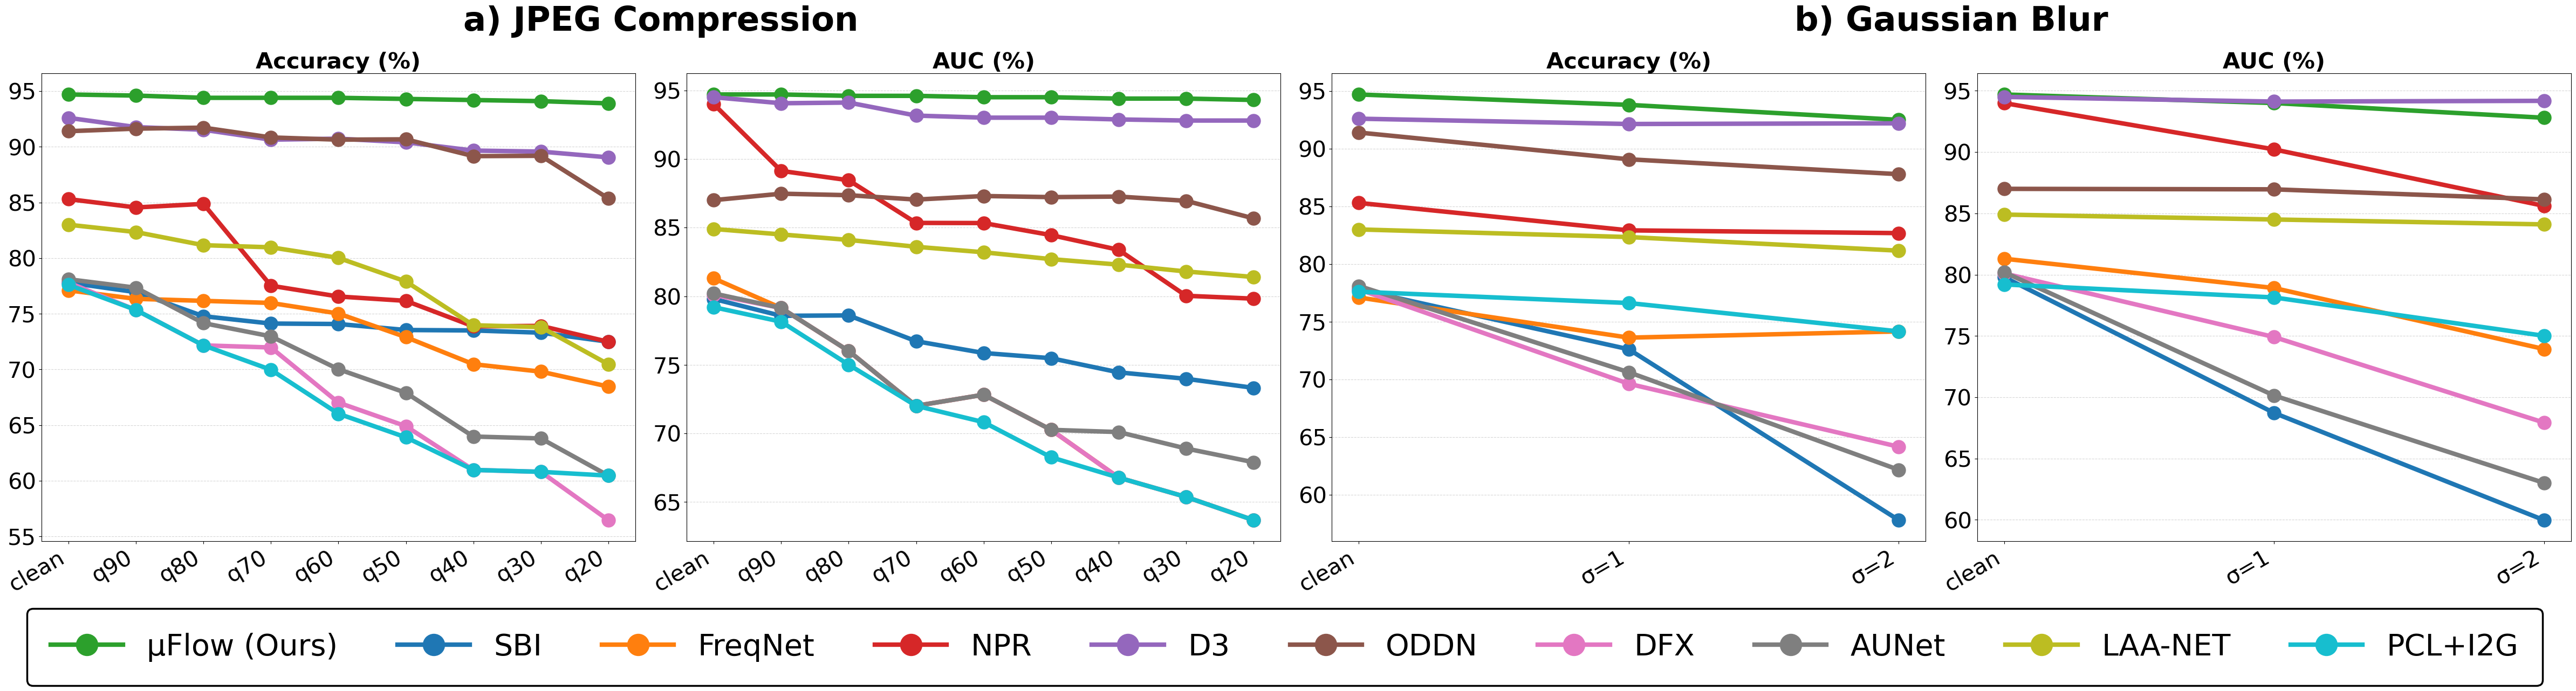

In [2]:
import numpy as np

### MuFlow ###

muflow_jpeg_acc = [94.7, 94.6, 94.4, 94.4, 94.4, 94.3, 94.2, 94.1, 93.9]
muflow_jpeg_auc = [94.7, 94.7, 94.6, 94.6, 94.5, 94.5, 94.4, 94.4, 94.3]

muflow_blur_acc = [94.7, 93.8, 92.5]
muflow_blur_auc = [94.7, 94.0, 92.8]

### Metodo SBI ###

SBI_jpeg_acc = [77.8, 76.94, 74.78, 74.12, 74.08, 73.54, 73.50, 73.30, 72.49]
SBI_jpeg_auc = [79.8, 78.57, 78.60, 76.72, 75.86, 75.48, 74.45, 73.98, 73.32]

SBI_blur_acc = [77.8, 72.61, 57.80]
SBI_blur_auc = [79.8, 68.72, 59.97]

### Metodo DFX ###

DFX_jpeg_acc = [77.8, 75.34, 72.16, 71.97, 67.02, 64.90, 60.97, 60.80, 56.46]
DFX_jpeg_auc = [80.1, 79.14, 76.01, 72.01, 72.82, 70.26, 66.78, 65.37, 63.68]

DFX_blur_acc = [77.8, 69.62, 64.16]
DFX_blur_auc = [80.1, 74.91, 67.93]

### Metodo FreqNet ###

FreqNet_jpeg_acc = [77.1, 76.34, 76.16, 75.97, 75.02, 72.90, 70.47, 69.80, 68.46]
FreqNet_jpeg_auc = [81.3, 79.14, 76.01, 72.01, 72.82, 70.26, 66.78, 65.37, 63.68]

FreqNet_blur_acc = [77.1, 73.62, 74.16]
FreqNet_blur_auc = [81.3, 78.91, 73.93]

### Metodo NPR ###

NPR_jpeg_acc = [85.3, 84.55, 84.87, 77.52, 76.55, 76.16, 73.87, 73.91, 72.48]
NPR_jpeg_auc = [94.0, 89.13, 88.45, 85.34, 85.33, 84.45, 83.38, 80.03, 79.82]

NPR_blur_acc = [85.3, 82.92, 82.68]
NPR_blur_auc = [94.0, 90.22, 85.61]

### Metodo D3 ###

D3_jpeg_acc = [92.6, 91.77, 91.53, 90.64, 90.73, 90.40, 89.66, 89.57, 89.05]
D3_jpeg_auc = [94.5, 94.06, 94.11, 93.16, 93.01, 93.01, 92.88, 92.8, 92.80]

D3_blur_acc = [92.6, 92.14, 92.20]
D3_blur_auc = [94.5, 94.12, 94.18]

### Metodo ODDN ###

ODDN_jpeg_acc = [91.4, 91.63, 91.72, 90.84, 90.64, 90.67, 89.16, 89.19, 85.36]
ODDN_jpeg_auc = [87.0, 87.47, 87.36, 87.04, 87.30, 87.22, 87.26, 86.95, 85.67]

ODDN_blur_acc = [91.4, 89.08, 87.79]
ODDN_blur_auc = [87.0, 86.96, 86.14]

### Metodo PCL+I2G ###

PCL_I2G_jpeg_acc = [77.6, 75.34, 72.16, 69.97, 66.02, 63.90, 60.97, 60.80, 60.46]
PCL_I2G_jpeg_auc = [79.2, 78.14, 75.01, 72.01, 70.82, 68.26, 66.78, 65.37, 63.68]

PCL_I2G_blur_acc = [77.6, 76.62, 74.16]
PCL_I2G_blur_auc = [79.2, 78.14, 75.01]

### Metodo AUNet ###

AUNet_jpeg_acc = [78.1, 77.34, 74.16, 72.97, 70.02, 67.90, 63.97, 63.80, 60.46]
AUNet_jpeg_auc = [80.2, 79.14, 76.01, 72.01, 72.82, 70.26, 70.10, 68.9, 67.9]

AUNet_blur_acc = [78.1, 70.62, 62.16]
AUNet_blur_auc = [80.2, 70.14, 63.01]

### Metodo LAA-NET ###

LAA_NET_jpeg_acc = [83.0, 82.34, 81.16, 80.97, 80.02, 77.90, 73.97, 73.80, 70.46]
LAA_NET_jpeg_auc = [84.9, 84.5, 84.1, 83.6, 83.2, 82.7, 82.3, 81.8, 81.4]

LAA_NET_blur_acc = [83.0, 82.34, 81.16]
LAA_NET_blur_auc = [84.9, 84.5, 84.1]

import matplotlib.pyplot as plt

jpeg_x = list(range(len(muflow_jpeg_acc)))
blur_x = list(range(len(muflow_blur_acc)))

method_data = {
    'μFlow (Ours)':   {'jpeg_acc': muflow_jpeg_acc,  'jpeg_auc': muflow_jpeg_auc,
                 'blur_acc': muflow_blur_acc,  'blur_auc': muflow_blur_auc},
    'SBI':      {'jpeg_acc': SBI_jpeg_acc,     'jpeg_auc': SBI_jpeg_auc,
                 'blur_acc': SBI_blur_acc,     'blur_auc': SBI_blur_auc},
    'FreqNet':  {'jpeg_acc': FreqNet_jpeg_acc, 'jpeg_auc': FreqNet_jpeg_auc,
                 'blur_acc': FreqNet_blur_acc, 'blur_auc': FreqNet_blur_auc},
    'NPR':      {'jpeg_acc': NPR_jpeg_acc,     'jpeg_auc': NPR_jpeg_auc,
                 'blur_acc': NPR_blur_acc,     'blur_auc': NPR_blur_auc},
    'D3':       {'jpeg_acc': D3_jpeg_acc,      'jpeg_auc': D3_jpeg_auc,
                 'blur_acc': D3_blur_acc,      'blur_auc': D3_blur_auc},
    'ODDN':     {'jpeg_acc': ODDN_jpeg_acc,    'jpeg_auc': ODDN_jpeg_auc,
                 'blur_acc': ODDN_blur_acc,    'blur_auc': ODDN_blur_auc},
    'DFX':      {'jpeg_acc': DFX_jpeg_acc,     'jpeg_auc': DFX_jpeg_auc,
                 'blur_acc': DFX_blur_acc,     'blur_auc': DFX_blur_auc},
    'AUNet':    {'jpeg_acc': AUNet_jpeg_acc,  'jpeg_auc': AUNet_jpeg_auc,
                 'blur_acc': AUNet_blur_acc,  'blur_auc': AUNet_blur_auc},
    'LAA-NET':  {'jpeg_acc': LAA_NET_jpeg_acc, 'jpeg_auc': LAA_NET_jpeg_auc,
                 'blur_acc': LAA_NET_blur_acc, 'blur_auc': LAA_NET_blur_auc},
    'PCL+I2G':  {'jpeg_acc': PCL_I2G_jpeg_acc, 'jpeg_auc': PCL_I2G_jpeg_auc,
                 'blur_acc': PCL_I2G_blur_acc, 'blur_auc': PCL_I2G_blur_auc},
}

method_colors = {
    'μFlow (Ours)':  '#2ca02c',
    'SBI':     '#1f77b4',
    'FreqNet': '#ff7f0e',
    'NPR':     '#d62728',
    'D3':      '#9467bd',
    'ODDN':    '#8c564b',
    'DFX':     '#e377c2',
    'AUNet':   '#7f7f7f',
    'LAA-NET': '#bcbd22',
    'PCL+I2G': '#17becf'
}

jpeg_xticks = ['clean', 'q90', 'q80', 'q70', 'q60', 'q50', 'q40', 'q30', 'q20']
blur_xticks = ['clean', 'σ=1', 'σ=2']

subplots_cfg = [
    ('jpeg_acc', 'Accuracy (%)', jpeg_xticks),
    ('jpeg_auc', 'AUC (%)',      jpeg_xticks),
    ('blur_acc', 'Accuracy (%)', blur_xticks),
    ('blur_auc', 'AUC (%)',      blur_xticks),
]

n_methods = len(method_data)
fig, axes = plt.subplots(1, 4, figsize=(48,12))

for ax, (key, title, xtick_labels) in zip(axes, subplots_cfg):
    n_groups = len(xtick_labels)
    x = np.arange(n_groups)

    for mname, mvals in method_data.items():
        vals = mvals[key]
        ax.plot(x, vals, marker='o', label=mname,
                color=method_colors[mname], linewidth=5, markersize=10)

    ax.set_title(title, fontsize=30, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, fontsize=30, rotation=30, ha='right')
    # ax.set_ylabel('Score (%)', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='y', labelsize=30)  # y-ticks più grandi

plt.tight_layout()
plt.subplots_adjust(top=0.82)  # make room for group titles

# Get positions of axes to center group titles
pos0 = axes[0].get_position()
pos1 = axes[1].get_position()
pos2 = axes[2].get_position()
pos3 = axes[3].get_position()

mid_jpeg = (pos0.x0 + pos1.x1) / 2
mid_blur = (pos2.x0 + pos3.x1) / 2

fig.text(mid_jpeg, 0.90, 'a) JPEG Compression', ha='center', va='center',
         fontsize=45, fontweight='bold')
fig.text(mid_blur, 0.90, 'b) Gaussian Blur', ha='center', va='center',
         fontsize=45, fontweight='bold')

# Applica stile linee/marker a tutti i subplot
for ax in axes:
    for line in ax.get_lines():
        line.set_markersize(18)   # pallini più grandi
        line.set_linewidth(6)     # linea più visibile

# Prende handle/label unici da tutti i grafici (evita duplicati)
handles, labels = [], []
seen = set()
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in seen:
            handles.append(hh)
            labels.append(ll)
            seen.add(ll)

legend = fig.legend(
    handles, labels,
    loc='lower center',
    ncol=n_methods,
    bbox_to_anchor=(0.5, -0.15),
    fontsize=40,
    frameon=True,
    markerscale=1.6,
    handlelength=2.4,
    handletextpad=0.8,
    borderpad=0.8,
    labelspacing=0.8,
    framealpha=1.0
)

legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(2.5)

plt.savefig('robustness_lineplots.png', dpi=400, bbox_inches='tight')
plt.show()
plt.close()
